# LIBERO Trial Inspection — multi-failure contact clouds

For one LIBERO demo + pre-failure pose, run **every** failure mode against the same checkpoint, then visualise each one's *failure-induced* contact cloud separately.

Why this matters: `ContactExtractor` records every contact above 1 N every settle step, so the raw `aggregate_contacts` is dominated by **baseline contacts** that already existed at the failure instant — gripper holding bowl, two cabinet drawers touching, table-on-floor, etc. The interesting signal is contacts that *first appeared* after the failure was injected.

This notebook computes a baseline `(geom1, geom2)` pair set by replaying kinematically up to the failure step in a separate sim, then filters each failure mode's contacts into:

- **baseline** — pair was already in contact pre-failure (greyed out in plots)
- **induced** — pair contacted only after the failure (highlighted)

Every cell uses the same demo and same `fail_progress`; only the failure mode changes between forks.

In [1]:
import os, sys
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import mujoco

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

HDF5_PATH = "datasets/libero/raw/libero_spatial/pick_up_the_black_bowl_on_the_stove_and_place_it_on_the_plate_demo.hdf5"
DEMO_KEY = "demo_0"
FAIL_PROGRESS = 0.55
RESISTANCE = "gravcomp_pd"   # "none" | "gravcomp_pd" — gravcomp_pd makes failures legible

In [2]:
from planner.experiments.config import FailureConfig, FailureMode
from planner.experiments.libero.adapter import list_demos, load_demo, materialise_mjcf
from planner.experiments.libero.naming import resolve_model_handles
from planner.experiments.libero.runner import LiberoRunner, LiberoTrialConfig
from planner.experiments.data_capture import ContactProjector

demo = load_demo(HDF5_PATH, DEMO_KEY)
model = mujoco.MjModel.from_xml_path(materialise_mjcf(demo.model_xml))
T = demo.arm_qpos.shape[0]
fail_idx = max(1, min(int(FAIL_PROGRESS * (T - 1)), T - 1))
print(f"demo {DEMO_KEY}: T={T}  fail_idx={fail_idx}  task={demo.task_id}")

demo demo_0: T=155  fail_idx=84  task=libero/pick_up_the_black_bowl_on_the_stove_and_place_it_on_the_plate_demo


## Step 1 — baseline contact pairs

Replay kinematically up to `fail_idx` in a fresh sim, then snapshot the set of `(geom1, geom2)` pairs currently in contact. These are the contacts that already exist at the failure instant; anything new in the post-failure cloud is failure-induced.

In [3]:
def kinematic_step(model, data, h, arm_q, finger_q):
    for adr, q in zip(h.arm_qpos_adrs, arm_q):
        data.qpos[adr] = q
    if len(h.finger_qpos_adrs) == 2:
        for adr, q in zip(h.finger_qpos_adrs, finger_q):
            data.qpos[adr] = q
    for adr in h.arm_dof_adrs:
        data.qvel[adr] = 0.0
    for adr in h.finger_dof_adrs:
        data.qvel[adr] = 0.0
    mujoco.mj_forward(model, data)

def normalise_pair(g1, g2):
    return (int(g1), int(g2)) if int(g1) <= int(g2) else (int(g2), int(g1))

# Map every geom -> its top-level scene entity (the body whose parent is world).
# Robosuite groups all robot geoms under multiple links, so we collapse the entire
# robot to a single "robot" entity rather than walking past it.
def build_entity_map(model, robot_prefixes=("robot0_", "gripper0_", "mount0_")):
    ent = np.zeros(model.ngeom, dtype=np.int64)
    # Use negative ids for synthetic entities so they don't collide with body ids.
    ROBOT_ENT = -1
    WORLD_ENT = 0  # world body
    for gid in range(model.ngeom):
        bid = int(model.geom_bodyid[gid])
        bname = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, bid) or ""
        if bname.startswith(robot_prefixes):
            ent[gid] = ROBOT_ENT
            continue
        # Walk up to the body whose parent is the world body (parent_id == 0 and
        # itself != 0).
        cur = bid
        while cur > 0 and int(model.body_parentid[cur]) > 0:
            cur = int(model.body_parentid[cur])
        ent[gid] = cur
    return ent

def entity_label(model, eid, robot_prefixes=("robot0_", "gripper0_", "mount0_")):
    if eid == -1:
        return "robot"
    if eid == 0:
        return "world"
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, int(eid)) or f"body_{eid}"
    return name

def entity_pair(ent_map, g1, g2):
    a, b = int(ent_map[g1]), int(ent_map[g2])
    return (a, b) if a <= b else (b, a)

ENTITY_MAP = build_entity_map(model)
print(f"entity map: {model.ngeom} geoms -> {len(set(ENTITY_MAP))} unique scene entities")
sample_ents = sorted(set(int(e) for e in ENTITY_MAP))
for e in sample_ents:
    n_geoms = int((ENTITY_MAP == e).sum())
    print(f"  {e:>4}  {entity_label(model, e):40s}  ({n_geoms} geoms)")

_KP = np.array([600., 600., 600., 600., 300., 120., 120.])
_KD = 2 * np.sqrt(_KP)

def apply_resistance(model, data, h, target_qpos, failed=set()):
    """Mirror of LiberoRunner._apply_resistance — gravcomp + PD on healthy joints."""
    mujoco.mj_forward(model, data)
    for i, jid in enumerate(h.arm_joint_ids):
        if jid in failed:
            continue
        aid = h.arm_actuator_ids[i]
        if aid < 0:
            continue
        q = float(data.qpos[h.arm_qpos_adrs[i]])
        qd = float(data.qvel[h.arm_dof_adrs[i]])
        grav = float(data.qfrc_bias[h.arm_dof_adrs[i]])
        tau = grav + _KP[i] * (target_qpos[i] - q) - _KD[i] * qd
        lo, hi = model.actuator_ctrlrange[aid]
        data.ctrl[aid] = float(np.clip(tau, lo, hi))

def baseline_entity_pairs(model, demo, fail_idx, ent_map, min_force=1.0,
                          warmup_steps=200, sample_steps=300):
    """Reproduce the trial's pre-injection state, then sample contact entity-pairs.

    Returns a set of (entity_a, entity_b) tuples (with ids as built by
    build_entity_map). Same-entity pairs (cabinet-internal, robot-internal)
    are added unconditionally so that any later self-contact within those
    entities counts as baseline regardless of which specific geoms it hits.
    """
    data = mujoco.MjData(model)
    h = resolve_model_handles(model)
    if demo.init_state is not None:
        data.qpos[:model.nq] = demo.init_state[:model.nq]
        data.qvel[:model.nv] = demo.init_state[model.nq:model.nq + model.nv]
        mujoco.mj_forward(model, data)
    for t in range(fail_idx + 1):
        kinematic_step(model, data, h, demo.arm_qpos[t], demo.finger_qpos[t])
    target = demo.arm_qpos[fail_idx].astype(np.float64).copy()
    for _ in range(warmup_steps):
        apply_resistance(model, data, h, target)
        mujoco.mj_step(model, data)
    pairs = set()
    force_buf = np.zeros(6)
    for _ in range(sample_steps):
        apply_resistance(model, data, h, target)
        mujoco.mj_step(model, data)
        for i in range(data.ncon):
            c = data.contact[i]
            mujoco.mj_contactForce(model, data, i, force_buf)
            if np.linalg.norm(force_buf[:3]) >= min_force:
                pairs.add(entity_pair(ent_map, c.geom1, c.geom2))
    # Additionally, every (entity, entity) self-pair is baseline by definition:
    # internal drawer/finger contacts within an articulated body are scene
    # noise, not failure consequences.
    for e in set(int(x) for x in ent_map):
        pairs.add((e, e))
    return pairs

BASELINE_ENTITY_PAIRS = baseline_entity_pairs(model, demo, fail_idx, ENTITY_MAP)
print(f"\nbaseline entity-pairs: {len(BASELINE_ENTITY_PAIRS)} unique")
for e1, e2 in sorted(BASELINE_ENTITY_PAIRS)[:14]:
    print(f"  ({e1:>4}, {e2:>4})  {entity_label(model, e1):30s}  <->  {entity_label(model, e2):30s}")
if len(BASELINE_ENTITY_PAIRS) > 14:
    print(f"  ... and {len(BASELINE_ENTITY_PAIRS) - 14} more")

entity map: 271 geoms -> 10 unique scene entities
    -1  robot                                     (71 geoms)
     0  world                                     (7 geoms)
     1  table                                     (6 geoms)
    23  akita_black_bowl_1_main                   (41 geoms)
    24  akita_black_bowl_2_main                   (41 geoms)
    25  cookies_1_main                            (2 geoms)
    26  glazed_rim_porcelain_ramekin_1_main       (26 geoms)
    27  plate_1_main                              (11 geoms)
    28  wooden_cabinet_1_main                     (43 geoms)
    33  flat_stove_1_main                         (23 geoms)



baseline entity-pairs: 11 unique
  (  -1,   -1)  robot                           <->  robot                         
  (   0,    0)  world                           <->  world                         
  (   0,   23)  world                           <->  akita_black_bowl_1_main       
  (   1,    1)  table                           <->  table                         
  (  23,   23)  akita_black_bowl_1_main         <->  akita_black_bowl_1_main       
  (  24,   24)  akita_black_bowl_2_main         <->  akita_black_bowl_2_main       
  (  25,   25)  cookies_1_main                  <->  cookies_1_main                
  (  26,   26)  glazed_rim_porcelain_ramekin_1_main  <->  glazed_rim_porcelain_ramekin_1_main
  (  27,   27)  plate_1_main                    <->  plate_1_main                  
  (  28,   28)  wooden_cabinet_1_main           <->  wooden_cabinet_1_main         
  (  33,   33)  flat_stove_1_main               <->  flat_stove_1_main             


## Step 2 — run every failure mode against the same checkpoint

`failure_sample_mode="all"` runs every `FailureConfig` in the list against the same `SimStateCheckpoint`. Each mode produces its own `FailureResult` with its own contact list.

In [4]:
FAILURES = [
    FailureConfig(mode=FailureMode.GRIPPER_OPEN),
    FailureConfig(mode=FailureMode.SLIPPERY_GRIP, grip_value=180.0),
    FailureConfig(mode=FailureMode.SINGLE_JOINT, joint_names=["joint2"]),
    FailureConfig(mode=FailureMode.SINGLE_JOINT, joint_names=["joint4"]),
    FailureConfig(mode=FailureMode.SINGLE_JOINT, joint_names=["joint6"]),
    FailureConfig(mode=FailureMode.MULTI_JOINT, joint_names=["joint2", "joint4"]),
    FailureConfig(mode=FailureMode.ALL_JOINTS),
]

cfg = LiberoTrialConfig(
    fail_progress=FAIL_PROGRESS,
    failure_configs=FAILURES,
    failure_sample_mode="all",
    resistance_mode=RESISTANCE,
    seed=0,
)
runner = LiberoRunner(demo, cfg)
try:
    sample = runner.run()
finally:
    runner.close()

print(f"failure modes recorded: {len(sample.failure_results)}")
for fr in sample.failure_results:
    fc = fr.failure_config
    tag = fc.mode.name + (f"({','.join(fc.joint_names)})" if fc.joint_names else "")
    print(f"  {tag:32s} contacts={len(fr.contacts):5d}  collision={fr.had_collision}")

failure modes recorded: 7
  GRIPPER_OPEN                     contacts= 2055  collision=True
  SLIPPERY_GRIP                    contacts= 2055  collision=True
  SINGLE_JOINT(joint2)             contacts= 2370  collision=True
  SINGLE_JOINT(joint4)             contacts= 2055  collision=True
  SINGLE_JOINT(joint6)             contacts= 2055  collision=True
  MULTI_JOINT(joint2,joint4)       contacts= 2365  collision=True
  ALL_JOINTS                       contacts= 2390  collision=True


## Step 3 — split each mode's contacts into baseline vs induced

A contact is *induced* if its `(geom1, geom2)` pair was **not** in the baseline set. Anything in the baseline (gripper-bowl, cabinet-cabinet, etc.) is dropped from the "failure-induced" cloud.

In [5]:
def split_contacts(contacts, baseline_ent_pairs, ent_map):
    induced, base = [], []
    for c in contacts:
        if entity_pair(ent_map, c.geom1, c.geom2) in baseline_ent_pairs:
            base.append(c)
        else:
            induced.append(c)
    return induced, base

def label_for(fc):
    return fc.mode.name + (f"({','.join(fc.joint_names)})" if fc.joint_names else "")

print(f"{'mode':32s}  baseline  induced  unique-induced-entity-pairs")
print("-" * 82)
per_mode = {}
for fr in sample.failure_results:
    induced, base = split_contacts(fr.contacts, BASELINE_ENTITY_PAIRS, ENTITY_MAP)
    induced_pairs = {entity_pair(ENTITY_MAP, c.geom1, c.geom2) for c in induced}
    per_mode[label_for(fr.failure_config)] = (induced, base, induced_pairs)
    print(f"{label_for(fr.failure_config):32s}  {len(base):8d}  {len(induced):7d}  {len(induced_pairs):4d}")

mode                              baseline  induced  unique-induced-entity-pairs
----------------------------------------------------------------------------------
GRIPPER_OPEN                          1962       93     6
SLIPPERY_GRIP                         1962       93     6
SINGLE_JOINT(joint2)                  1962      408     7
SINGLE_JOINT(joint4)                  1962       93     6
SINGLE_JOINT(joint6)                  1962       93     6
MULTI_JOINT(joint2,joint4)            1962      403     7
ALL_JOINTS                            1962      428     7


## Step 4 — what each failure actually broke (top induced geoms)

Counts every contact whose pair is *new* against each geom; these are the entities the failure caused the robot to touch for the first time.

In [6]:
for label, (induced, base, _) in per_mode.items():
    if not induced:
        print(f"\n— {label} — no induced contacts (failure produced no new entity pairs)")
        continue
    counts = Counter()
    for c in induced:
        counts[int(ENTITY_MAP[c.geom1])] += 1
        counts[int(ENTITY_MAP[c.geom2])] += 1
    # Drop the robot's own count from the per-entity hit list — it's always
    # a participant; we want to see *what the robot or held object hit*.
    print(f"\n— {label} — top induced entities (excluding 'robot')")
    shown = 0
    for eid, n in counts.most_common():
        if eid == -1:  # robot
            continue
        print(f"   {entity_label(model, eid)[:42]:42s}  {n}")
        shown += 1
        if shown >= 6:
            break


— GRIPPER_OPEN — top induced entities (excluding 'robot')
   world                                       59
   cookies_1_main                              24
   table                                       24
   akita_black_bowl_1_main                     24
   akita_black_bowl_2_main                     23
   plate_1_main                                21

— SLIPPERY_GRIP — top induced entities (excluding 'robot')
   world                                       59
   cookies_1_main                              24
   table                                       24
   akita_black_bowl_1_main                     24
   akita_black_bowl_2_main                     23
   plate_1_main                                21

— SINGLE_JOINT(joint2) — top induced entities (excluding 'robot')
   table                                       339
   world                                       59
   cookies_1_main                              24
   akita_black_bowl_1_main                     24
   akita_blac

## Step 5 — induced contact cloud per failure mode

3D scatter of induced points only (greyed-out base would dominate; not shown). Colour = log force magnitude. One subplot per failure mode for easy comparison.

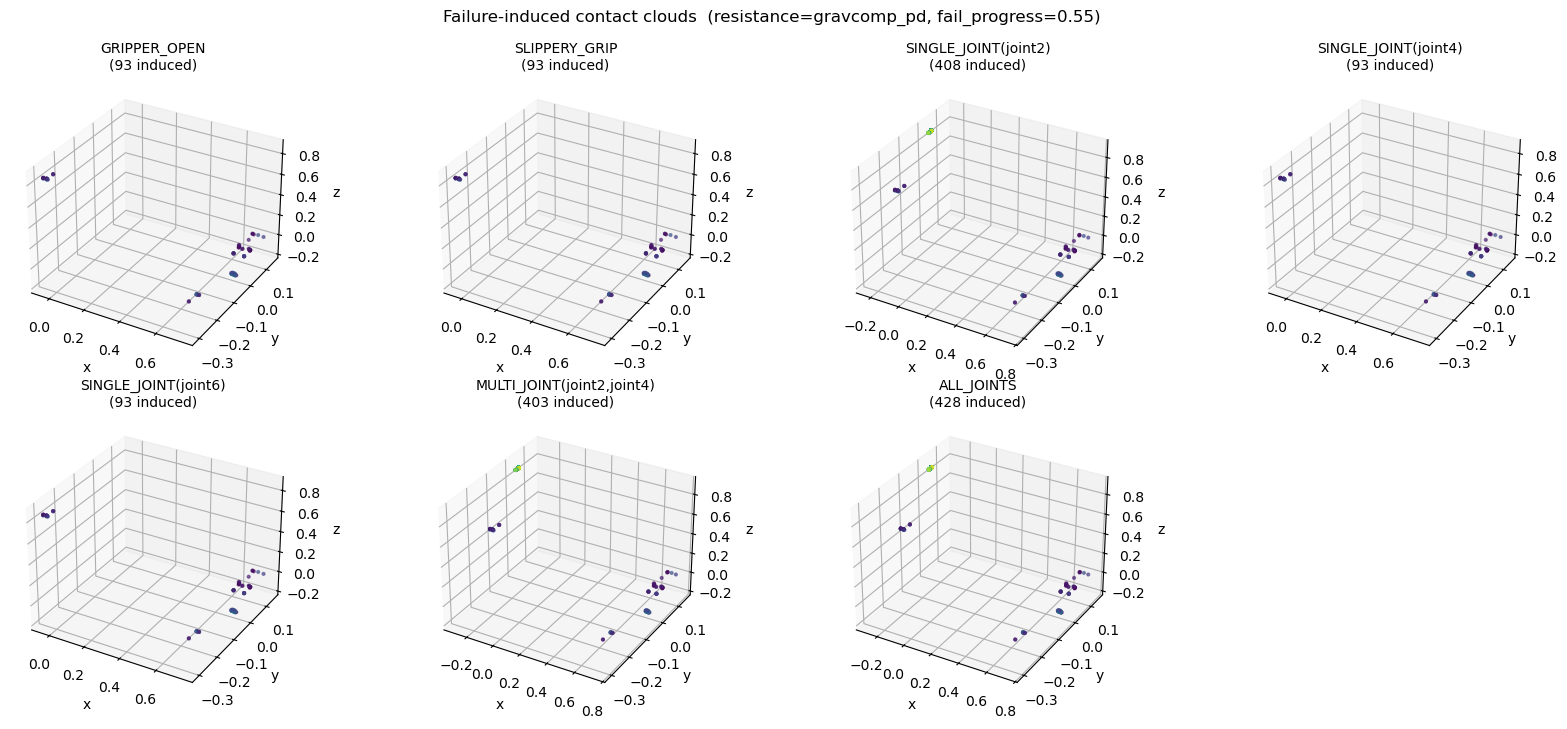

In [7]:
modes = list(per_mode.keys())
n = len(modes)
cols = 4
rows = (n + cols - 1) // cols
fig = plt.figure(figsize=(4.2 * cols, 3.6 * rows))

# Shared force scale so colours are comparable across modes.
all_induced_f = [np.linalg.norm(c.force[:3]) for _, (i, _, _) in per_mode.items() for c in i]
if all_induced_f:
    vmin, vmax = np.log10(min(all_induced_f) + 1e-3), np.log10(max(all_induced_f) + 1e-3)
else:
    vmin, vmax = 0, 1

for k, label in enumerate(modes):
    induced, _, _ = per_mode[label]
    ax = fig.add_subplot(rows, cols, k + 1, projection="3d")
    ax.set_title(f"{label}\n({len(induced)} induced)", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    if not induced:
        continue
    pos = np.array([c.pos for c in induced])
    fmag = np.linalg.norm(np.array([c.force[:3] for c in induced]), axis=1)
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2],
               c=np.log10(fmag + 1e-3), s=4, cmap="viridis",
               vmin=vmin, vmax=vmax, alpha=0.6)
plt.suptitle(f"Failure-induced contact clouds  (resistance={RESISTANCE}, fail_progress={FAIL_PROGRESS})")
plt.tight_layout()

## Step 6 — projected onto agentview

Each subplot overlays the *induced* contacts on the pre-failure agentview image. Baseline contacts are drawn first in light grey for context; induced points are red.

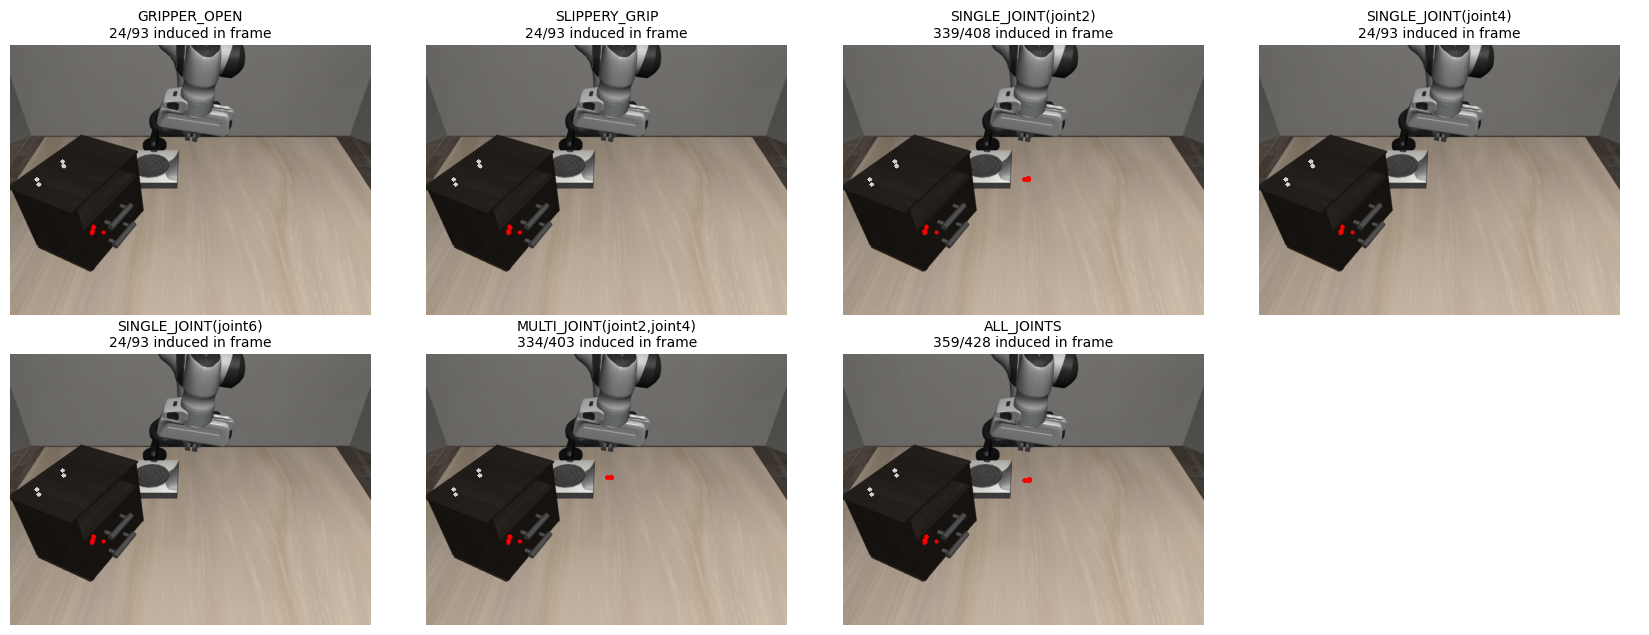

In [8]:
H, W = sample.pre_failure_rgb.shape[:2]
proj = ContactProjector(model, width=W, height=H, camera_name="agentview")
proj.validate()

fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.2 * rows), squeeze=False)
for k, label in enumerate(modes):
    induced, base, _ = per_mode[label]
    ax = axes[k // cols, k % cols]
    ax.imshow(sample.pre_failure_rgb)
    if base:
        bp = np.array([c.pos for c in base])
        bx, bd = proj.project(bp)
        bm = proj.in_frame(bx, bd)
        ax.scatter(bx[bm, 0], bx[bm, 1], c="lightgrey", s=2, alpha=0.3)
    if induced:
        ip = np.array([c.pos for c in induced])
        ix, idp = proj.project(ip)
        im = proj.in_frame(ix, idp)
        ax.scatter(ix[im, 0], ix[im, 1], c="red", s=3, alpha=0.55)
        title = f"{label}\n{im.sum()}/{len(induced)} induced in frame"
    else:
        title = f"{label}\nno induced contacts"
    ax.set_title(title, fontsize=10)
    ax.axis("off")
for k in range(n, rows * cols):
    axes[k // cols, k % cols].axis("off")
plt.tight_layout()

## Step 7 — pre + post agentview for each failure mode

The runner saves a single `post_rgb` (the post-settle image of the *last* failure mode it ran). To get one per mode, re-run with `failure_sample_mode="all"` once per mode and grab `post_rgb` each time. Cheap because each invocation reuses the same checkpoint internally; we pay the settle cost once per mode either way.

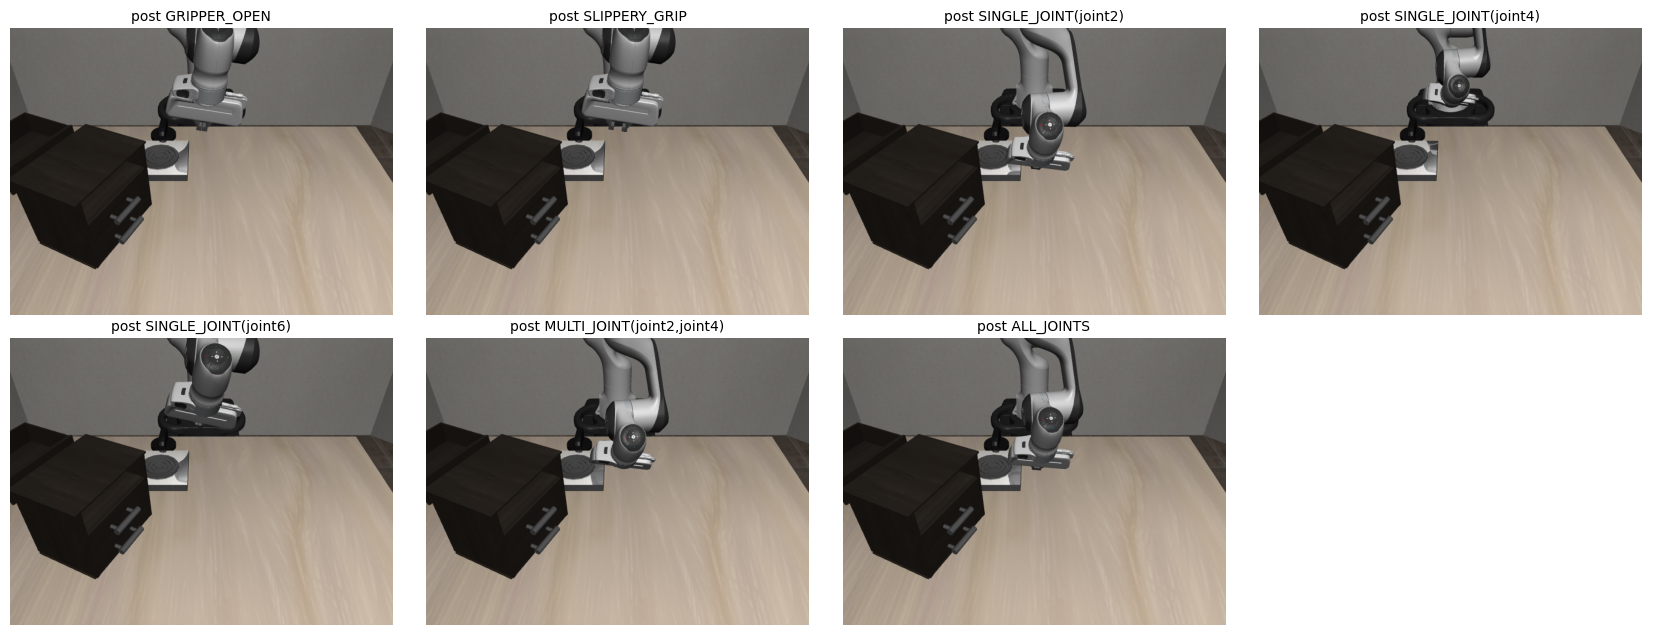

In [9]:
post_rgbs = {}
for fc in FAILURES:
    cfg2 = LiberoTrialConfig(
        fail_progress=FAIL_PROGRESS,
        failure_configs=[fc],
        resistance_mode=RESISTANCE,
        seed=0,
    )
    r = LiberoRunner(demo, cfg2)
    try:
        s = r.run()
        post_rgbs[label_for(fc)] = s.post_failure_rgb
    finally:
        r.close()

fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.2 * rows), squeeze=False)
for k, label in enumerate(modes):
    ax = axes[k // cols, k % cols]
    ax.imshow(post_rgbs[label])
    ax.set_title(f"post {label}", fontsize=10)
    ax.axis("off")
for k in range(n, rows * cols):
    axes[k // cols, k % cols].axis("off")
plt.tight_layout()